Data Merging and Master File Export

In [1]:
import pandas as pd
import numpy as np

# Define files and their corresponding Weff values
files = {
    40: "Grain2nm_lg16nm_weff40_vth_ion_ioff_simulated.csv",
    52: "Grain2nm_lg16nm_weff52_vth_ion_ioff_simulated.csv",
    60: "Grain2nm_lg16nm_weff60_vth_ion_ioff_simulated.csv"
}

dfs = []
for weff, file in files.items():
    # Load data skipping metadata rows
    df = pd.read_csv(file, header=2)
    # Remove unnamed columns
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    # Label the data with its physical dimension
    df['Weff'] = weff
    dfs.append(df)

# Concatenate all data
master_df = pd.concat(dfs, ignore_index=True)

# Data Cleaning: Ensure numeric types for current-related columns
master_df['OnCurrent'] = pd.to_numeric(master_df['OnCurrent'], errors='coerce')
master_df['OffCurrent'] = pd.to_numeric(master_df['OffCurrent'], errors='coerce')
master_df.dropna(inplace=True)

# Save the Master CSV file for GitHub/Research records
master_df.to_csv('Master_Device_Simulations.csv', index=False)
print("Master dataset saved as 'Master_Device_Simulations.csv'")

Master dataset saved as 'Master_Device_Simulations.csv'


Advanced Preprocessing

We prepare the seed embeddings and apply log-scaling to the targets.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Prepare Features: Seed Index (0-indexed) and Weff
master_df['seed_idx'] = master_df['seed'].astype(int) - 1
num_seeds = master_df['seed'].nunique()

# 2. Target Transformation: Log-scaling for currents
master_df['log_Ioff'] = np.log10(master_df['OffCurrent'])
master_df['log_Ion'] = np.log10(master_df['OnCurrent'])

X_weff = master_df[['Weff']].values
X_seed = master_df['seed_idx'].values
y = master_df[['Vth', 'log_Ioff', 'log_Ion']].values

# 3. Train-Test Split (80/20)
indices = np.arange(len(master_df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

# 4. Scaling: Standardizing Weff and Targets
scaler_weff = StandardScaler()
scaler_y = StandardScaler()

X_weff_train = scaler_weff.fit_transform(X_weff[train_idx])
X_weff_test = scaler_weff.transform(X_weff[test_idx])

X_seed_train = X_seed[train_idx]
X_seed_test = X_seed[test_idx]

y_train_scaled = scaler_y.fit_transform(y[train_idx])
y_test_scaled = scaler_y.transform(y[test_idx])

print("Data preprocessing with scaling and embeddings ready.")

Data preprocessing with scaling and embeddings ready.


Refined ANN Architecture and Training

This block implements Batch Normalization, the Swish activation function, and Learning Rate Scheduling.


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

def build_refined_model(num_seeds):
    # Branch 1: Numerical Geometries
    input_weff = layers.Input(shape=(1,), name='Weff_Input')
    x1 = layers.Dense(32, activation='swish')(input_weff)
    x1 = layers.BatchNormalization()(x1)

    # Branch 2: Seed Embeddings (captures grain-specific variation)
    input_seed = layers.Input(shape=(1,), name='Seed_Input')
    emb_seed = layers.Embedding(input_dim=num_seeds, output_dim=20)(input_seed)
    emb_seed = layers.Flatten()(emb_seed)

    # Merge branches
    merged = layers.Concatenate()([x1, emb_seed])

    # Deep architecture with Regularization
    x = layers.Dense(128, activation='swish')(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x) # Prevents overfitting to specific training seeds

    x = layers.Dense(64, activation='swish')(x)
    x = layers.Dense(32, activation='swish')(x)

    output = layers.Dense(3, name='Output')(x)
    return models.Model(inputs=[input_weff, input_seed], outputs=output)

# Callbacks for optimal convergence
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, min_lr=1e-6)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

model = build_refined_model(num_seeds)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.002), loss='mse')

print("Starting training...")
history = model.fit(
    [X_weff_train, X_seed_train], y_train_scaled,
    epochs=1000, batch_size=32, validation_split=0.2,
    callbacks=[lr_scheduler, early_stop], verbose=0
)
print("Training complete.")

Starting training...
Training complete.


Metrics Calculation and Saving Scores

In [4]:
from sklearn.metrics import mean_squared_error, r2_score
import json

# Predictions and Inverse Scaling
y_pred_scaled = model.predict([X_weff_test, X_seed_test])
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = y[test_idx]

targets = ['Vth', 'log_Ioff', 'log_Ion']
performance_results = {}

print("\n--- Model Performance ---")
for i, target in enumerate(targets):
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    performance_results[target] = {"RMSE": round(rmse, 6), "R2": round(r2, 6)}
    print(f"{target} -> RMSE: {rmse:.6f}, R2 Score: {r2:.6f}")

# Save scores to a JSON/Text file
with open('accuracy_metrics.json', 'w') as f:
    json.dump(performance_results, f, indent=4)
print("\nAccuracy scores saved as 'accuracy_metrics.json'")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

--- Model Performance ---
Vth -> RMSE: 0.004790, R2 Score: 0.883783
log_Ioff -> RMSE: 0.083461, R2 Score: 0.953672
log_Ion -> RMSE: 0.003780, R2 Score: 0.998084

Accuracy scores saved as 'accuracy_metrics.json'


Research Plot Generation and Export

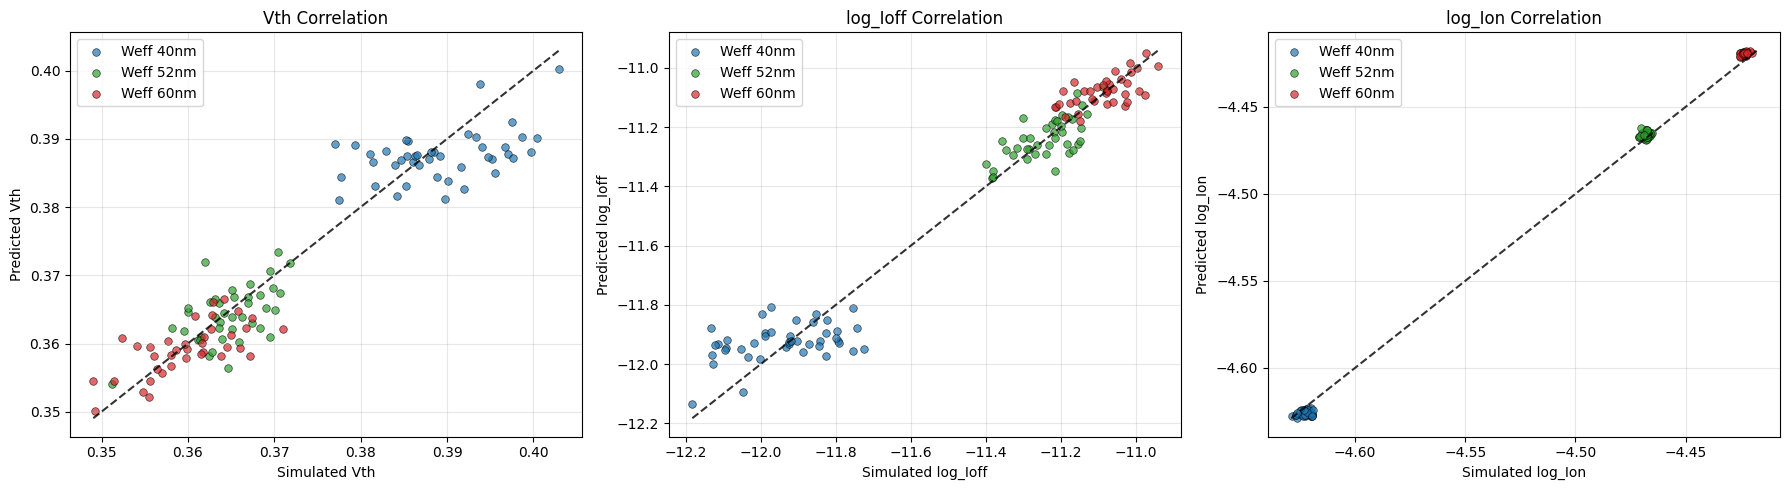

Plots saved as 'Device_Performance_Correlation_Plots.png'


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
weff_vals = X_weff[test_idx].flatten()
colors = {40: '#1f77b4', 52: '#2ca02c', 60: '#d62728'}

for i, target in enumerate(targets):
    plt.subplot(1, 3, i+1)
    for w in [40, 52, 60]:
        mask = (weff_vals == w)
        plt.scatter(y_true[mask, i], y_pred[mask, i],
                    color=colors[w], alpha=0.7, label=f'Weff {w}nm',
                    s=30, edgecolors='k', linewidth=0.5)

    # Diagonal line
    all_vals = np.concatenate([y_true[:, i], y_pred[:, i]])
    plt.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()], 'k--', alpha=0.8)

    plt.xlabel(f'Simulated {target}')
    plt.ylabel(f'Predicted {target}')
    plt.title(f'{target} Correlation')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
# Save as high-resolution PNG for your research paper
plt.savefig('Device_Performance_Correlation_Plots.png', dpi=300)
plt.show()
print("Plots saved as 'Device_Performance_Correlation_Plots.png'")